In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    HybridPoolingV0(30),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 60, 3, padding=1, groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60),          # 8 → 4

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60),          # 4 → 2

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model39_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model39_0)
describe(model39_0)

MACs: 4.37 MMac, Params: 22.11 k
Layer (type:depth-idx)                        Output Shape              Param #
BaseModelF32                                  [1, 10]                   --
├─ModuleList: 1-1                             --                        --
│    └─Sequential: 2-1                        [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1                  [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                       [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9                  [1, 30, 32, 32] 

Loading checkpoint from model_weights/model39_0.pt
Starting
Epoch 1/60: Train loss = 1.0671, Train accuracy = 0.6277, Test loss = 1.0775, Test accuracy = 0.6329
Epoch 2/60: Train loss = 0.8633, Train accuracy = 0.6984, Test loss = 0.8466, Test accuracy = 0.7132
Epoch 3/60: Train loss = 0.7697, Train accuracy = 0.7326, Test loss = 0.7787, Test accuracy = 0.7384
Epoch 4/60: Train loss = 0.6835, Train accuracy = 0.7613, Test loss = 0.6941, Test accuracy = 0.7648
Epoch 5/60: Train loss = 0.6954, Train accuracy = 0.7557, Test loss = 0.7173, Test accuracy = 0.7540
Epoch 6/60: Train loss = 0.6210, Train accuracy = 0.7844, Test loss = 0.6527, Test accuracy = 0.7722
Epoch 7/60: Train loss = 0.6434, Train accuracy = 0.7742, Test loss = 0.6826, Test accuracy = 0.7724
Epoch 8/60: Train loss = 0.7355, Train accuracy = 0.7496, Test loss = 0.7701, Test accuracy = 0.7456
Epoch 9/60: Train loss = 0.5882, Train accuracy = 0.7967, Test loss = 0.6506, Test accuracy = 0.7836
Epoch 10/60: Train loss = 0.538

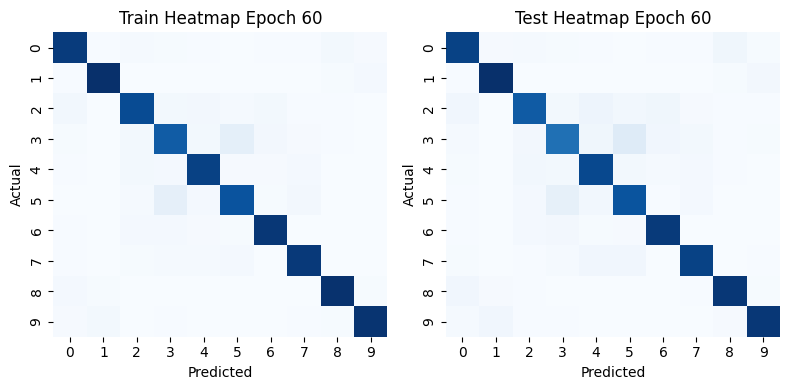

<Figure size 1200x600 with 0 Axes>

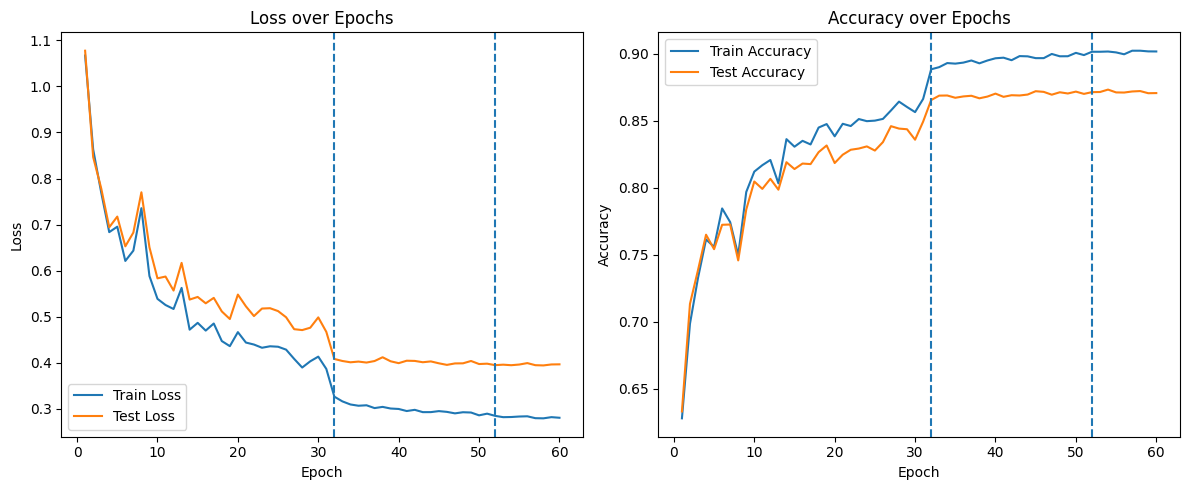

In [6]:
trainf32(model39_0,"model_weights/model39_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model39_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model39_1)
describe(model39_1)

MACs: 4.37 MMac, Params: 22.11 k
Layer (type:depth-idx)                        Output Shape              Param #
BaseModelF32                                  [1, 10]                   --
├─ModuleList: 1-1                             --                        --
│    └─Sequential: 2-1                        [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1                  [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                       [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9                  [1, 30, 32, 32] 

Loading checkpoint from model_weights/model39_1.pt
Starting
Epoch 1/60: Train loss = 0.9901, Train accuracy = 0.6511, Test loss = 0.9633, Test accuracy = 0.6592
Epoch 2/60: Train loss = 0.8503, Train accuracy = 0.7015, Test loss = 0.8361, Test accuracy = 0.7131
Epoch 3/60: Train loss = 0.7765, Train accuracy = 0.7317, Test loss = 0.7601, Test accuracy = 0.7375
Epoch 4/60: Train loss = 0.6662, Train accuracy = 0.7664, Test loss = 0.6847, Test accuracy = 0.7661
Epoch 5/60: Train loss = 0.6575, Train accuracy = 0.7716, Test loss = 0.6960, Test accuracy = 0.7614
Epoch 6/60: Train loss = 0.5770, Train accuracy = 0.7976, Test loss = 0.5839, Test accuracy = 0.7995
Epoch 7/60: Train loss = 0.5499, Train accuracy = 0.8097, Test loss = 0.5749, Test accuracy = 0.8014
Epoch 8/60: Train loss = 0.5550, Train accuracy = 0.8079, Test loss = 0.6016, Test accuracy = 0.7953
Epoch 9/60: Train loss = 0.5237, Train accuracy = 0.8197, Test loss = 0.5581, Test accuracy = 0.8063
Epoch 10/60: Train loss = 0.570

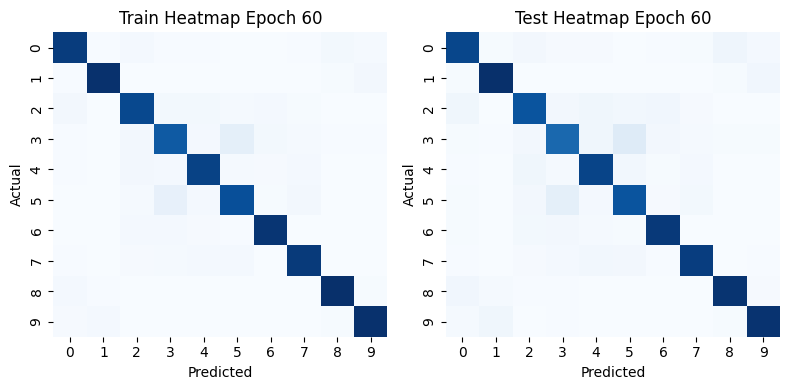

<Figure size 1200x600 with 0 Axes>

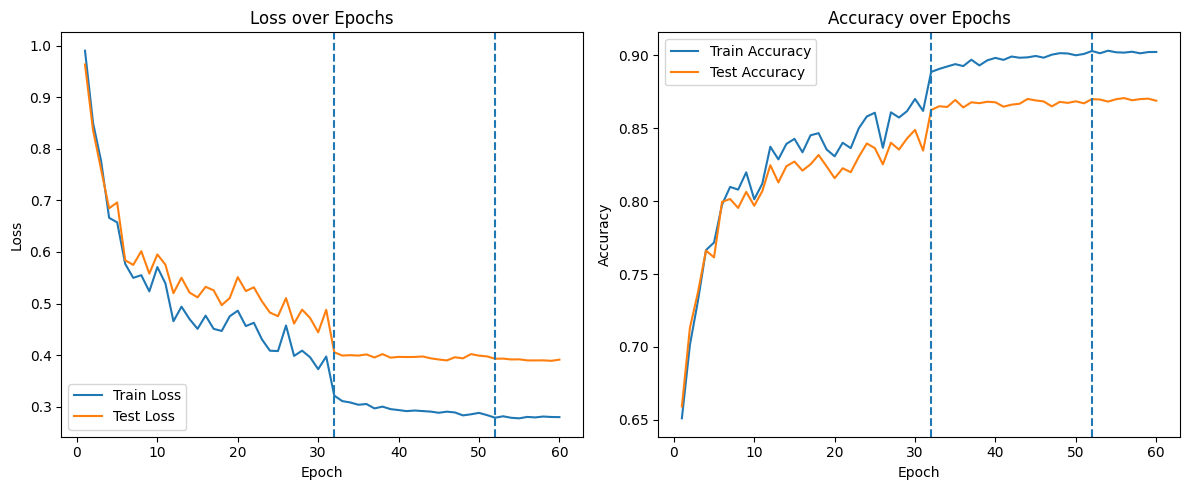

In [8]:
trainf32(model39_1,"model_weights/model39_1.pt",criterion,train_dataset,val_dataset, batch_size=64)